In [ ]:
import torch
import torch.nn as nn
import matplotlib as plt

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate circle data ONCE — reuse for all parts
torch.manual_seed(42)
# TODO: why set a seed here? what does it actually do?
# manual seed keeps the randomness consistent
# 42 is the key that determines which random sequence you get.
#So the number is basically a label for the starting state of the random-number generator
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

# --- ONE HIDDEN LAYER (Day 35 model) ---
class OneLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 8)
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.output(x)

# --- TWO HIDDEN LAYERS ---
class TwoLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 8)
        self.hidden2 = nn.Linear(8, 8)  # TODO: why is this (8, 8) and not (2, 8)?
        # becasue it is getting 8 inputs from previous hidden layer and then iut givees 8 outputs to output layer as input
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))  # TODO: does this need relu too? think before answering
        #yes , it does because without it would be just a linear layer but not a activation layer for our non linear data
        return self.output(x)

loss_fn = nn.BCEWithLogitsLoss()
EPOCHS = 1000

def train(model, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

losses_one = train(OneLayerModel())
losses_two = train(TwoLayerModel())

print("One layer final loss:", losses_one[-1])
print("Two layer final loss:", losses_two[-1])
print("Did depth help?") # kinda like its still the same
#One layer final loss: 0.6274141669273376
#Two layer final loss: 0.6078097820281982

One layer final loss: 0.6274141669273376
Two layer final loss: 0.6078097820281982
Did depth help?


**Checkpoint:** Run this and write down both final losses. Did your Q1 guess hold? If the two-layer model performed worse or the same, that's real information — not a failure, a result worth understanding.

**One layer final loss: 0.6274141669273376Two layer final loss: 0.6078097820281982**

*i think there is not much of a less in the loss , as just about 0.2 is the difference , even after using another hidden layer , it performed the same , the depth of activation didnt work that beneficial in this case.*

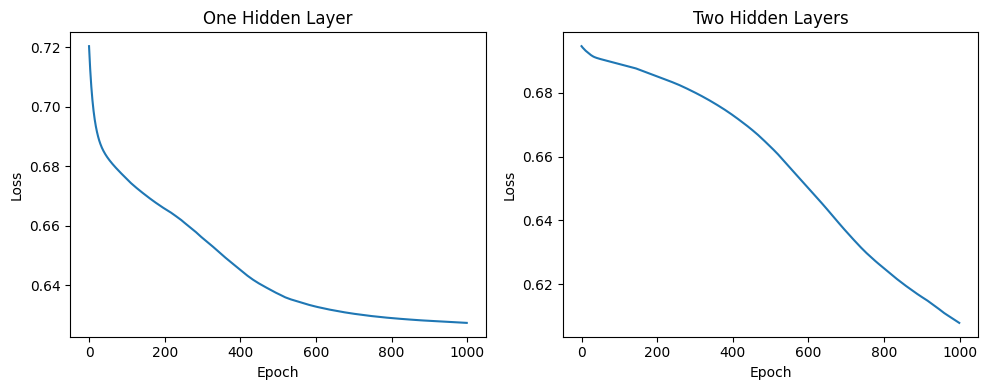

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_one)
plt.title("One Hidden Layer")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(losses_two)
plt.title("Two Hidden Layers")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

**Answer these before moving to Part 3:**
1. Does one curve converge faster than the other (reaches a low loss in fewer epochs)?
2. Does either curve spike or oscillate instead of smoothly going down? If yes, that's a learning rate issue — what would you change?
3. Where on each curve would you have stopped training if you had to pick an epoch manually?

**Predict-before-run, Q2:** What do you think happens to the loss curve if you train for 5000 epochs instead of 1000 — does it keep going down forever, or does it eventually stop improving?

##**Answer**
#1#
*one hidden layer model reach the low loss in lesser epochs than the two hidden layers , like the i layer model reach 0.68 loss in 100 epochs while 2 layer model needed 300 spochs to rach that , 1 layer model reached 0.64 loss in about 400 epochs while for 2 layer model even after 600 epochs it was still more tha 0.66 loss , 2 layer model becasue really steep after like reaching 0.65 loss till end*

#2#
*the model 1 goes down first then more or less its a curve but the model 2 is inverted curve more like spiked in start, no oscillatoions in them that are really recognizable*
#3#
*for 1 odel i think i would have stoppped it on thr 600 epcoh somewhere and for 2 model it is building through and through i think it needed the whole 1000 epochs*
#4#
*it think model 1 will stop training , after like 1200 epochs and model 2 wouls train till 200 epochs and then stop eventually improving*




In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate circle data ONCE — reuse for all parts
torch.manual_seed(42)
# TODO: why set a seed here? what does it actually do?
# manual seed keeps the randomness consistent
# 42 is the key that determines which random sequence you get.
#So the number is basically a label for the starting state of the random-number generator
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

# --- TWO HIDDEN LAYERS ---
class TwoLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 8)
        self.hidden2 = nn.Linear(8, 8)  # TODO: why is this (8, 8) and not (2, 8)?
        # becasue it is getting 8 inputs from previous hidden layer and then iut givees 8 outputs to output layer as input
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))  # TODO: does this need relu too? think before answering
        #yes , it does because without it would be just a linear layer but not a activation layer for our non linear data
        return self.output(x)

loss_fn = nn.BCEWithLogitsLoss()
EPOCHS = 5000

def train(model, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


losses_long = train(TwoLayerModel())
print("Two layer final loss:", losses_two[-1])

Two layer final loss: 0.5731872320175171


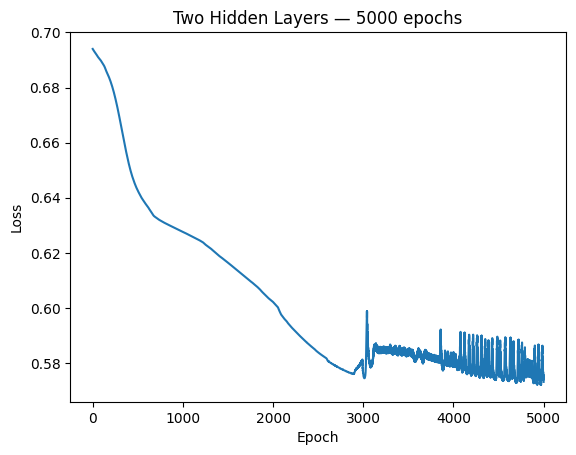

Final loss at 5000 epochs: 0.5731872320175171
Final loss at 1000 epochs: 0.5731872320175171


In [ ]:
plt.plot(losses_long)
plt.title("Two Hidden Layers — 5000 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("Final loss at 5000 epochs:", losses_long[-1])
print("Final loss at 1000 epochs:", losses_two[-1])

**Checkpoint:** Does the loss keep going down after epoch 1000, or does it flatline?

yes , it does till 3000 epoch and after 3000 epochs till 4000 spochs its one big till 0.60 oscillation , then a lot of small oscillations between 0.58 and 0.6 , then other big just before 4000 epoch and then its all big really close oscialltions like a a eartch quake pattern till 5000 which ends at 5.7





In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate circle data ONCE — reuse for all parts
torch.manual_seed(42)
# TODO: why set a seed here? what does it actually do?
# manual seed keeps the randomness consistent
# 42 is the key that determines which random sequence you get.
#So the number is basically a label for the starting state of the random-number generator
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

# --- TWO HIDDEN LAYERS ---
class LayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 8)
        self.hidden2 = nn.Linear(8, 8)  # TODO: why is this (8, 8) and not (2, 8)?
        # becasue it is getting 8 inputs from previous hidden layer and then iut givees 8 outputs to output layer as input
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))  # TODO: does this need relu too? think before answering
        #yes , it does because without it would be just a linear layer but not a activation layer for our non linear data
        return self.output(x)

loss_fn = nn.BCEWithLogitsLoss()
EPOCHS = 10000

def train(model, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


losses_long2 = train(LayerModel())
print("Two layer final loss:", losses_two[-1])

#yepp , now even with 10,000 epochs its doesnt go furthur down

Two layer final loss: 0.5731872320175171


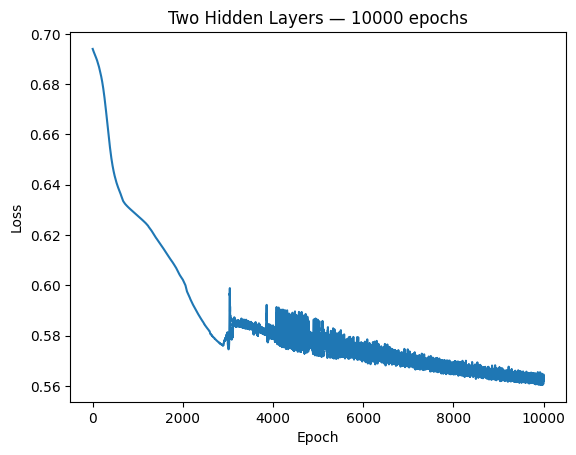

Final loss at 10000 epochs: 0.5618939995765686
Final loss at 5000 epochs: 0.5731872320175171


In [ ]:
plt.plot(losses_long2)
plt.title("Two Hidden Layers — 10000 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("Final loss at 10000 epochs:", losses_long2[-1])
print("Final loss at 5000 epochs:", losses_long[-1])

In [ ]:
def count_params(model):
    total = 0
    for param in model.parameters():
        total += param.numel()
    return total

print("One layer parameters:", count_params(OneLayerModel()))
print("Two layer parameters:", count_params(TwoLayerModel()))

One layer parameters: 33
Two layer parameters: 105


In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate circle data ONCE — reuse for all parts
torch.manual_seed(42)
# TODO: why set a seed here? what does it actually do?
# manual seed keeps the randomness consistent
# 42 is the key that determines which random sequence you get.
#So the number is basically a label for the starting state of the random-number generator
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

# --- TWO HIDDEN LAYERS ---
class ThreeLayerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 8)
        self.hidden2 = nn.Linear(8, 8)
        self.hidden3 = nn.Linear(8,8)
        # TODO: why is this (8, 8) and not (2, 8)?
        # becasue it is getting 8 inputs from previous hidden layer and then iut givees 8 outputs to output layer as input
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = torch.relu(self.hidden3(x))  # TODO: does this need relu too? think before answering
        #yes , it does because without it would be just a linear layer but not a activation layer for our non linear data
        return self.output(x)

loss_fn = nn.BCEWithLogitsLoss()
EPOCHS = 10000

def train(model, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


losses_three= train(ThreeLayerModel())
print("Three layer final loss:", losses_two[-1])

def count_params(model):
    total = 0
    for param in model.parameters():
        total += param.numel()
    return total

print("One layer parameters:", count_params(ThreeLayerModel()))

# TODO: Build ThreeLayerModel with hidden layers (2→8), (8→8), (8→8), output (8→1)
# Then print its parameter count
# How many parameters does each additional hidden layer of size 8 add?

Three layer final loss: 0.5731872320175171
One layer parameters: 177


In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate circle data ONCE — reuse for all parts
torch.manual_seed(42)
# TODO: why set a seed here? what does it actually do?
# manual seed keeps the randomness consistent
# 42 is the key that determines which random sequence you get.
#So the number is basically a label for the starting state of the random-number generator
X = torch.randn(100, 2)
distance = torch.sqrt(X[:, 0:1]**2 + X[:, 1:2]**2)
true_logit = -(distance - 1)
true_prob = torch.sigmoid(true_logit)
y = torch.bernoulli(true_prob)

class OverkillModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h1 = nn.Linear(2, 64)
        self.h2 = nn.Linear(64, 64)
        self.h3 = nn.Linear(64, 64)
        self.h4 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = torch.relu(self.h3(x))
        x = torch.relu(self.h4(x))
        return self.output(x)


loss_fn = nn.BCEWithLogitsLoss()
EPOCHS = 5000

def train(model, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())\

    return losses


losses_overkill = train(OverkillModel())
print("Overkill model final loss:", losses_overkill[-1])
print("One layer final loss:     ", losses_one[-1])
print("Three layer final loss:", losses_two[-1])

#Overkill model final loss: 0.0851924866437912
#One layer final loss:      0.6274141669273376
#Three layer final loss: 0.5731872320175171

#it kinda worked thoo but i think its the case where the low loss doesnt  mean it is efficient , overfitting i guess

Overkill model final loss: 0.0851924866437912
One layer final loss:      0.6274141669273376
Three layer final loss: 0.5731872320175171


1. How many parameters does OverkillModel have? (count by hand first, verify with `count_params`)
2. You have 100 training samples and potentially thousands of parameters — what does that ratio tell you?
3. Does OverkillModel have lower training loss than OneLayerModel? If yes, does that mean it's a better model? Why or why not?
4. What word describes a model with far more parameters than training samples?

#1)there are 12, 737 parameters for only 100 values , too much of a capacity


#2) the ratio tells me the parameters are less and the capacity of model exceeds so it is probably going to memorize the data instead of leaning the data

#3)overkill does have low training loss , but that doesnt mean we can calll it a successful model , cuz it may have probably memorixed the data and it would fail on other data when tested on test set , so it doesnt mean its better , it just have memorized data better

#4)overfitting model


## the jjournal questions i have answered most of it before , the 5 one is the one i am going to answer
*Post-seed check: the OverkillModel result is a post candidate — a massive model performing the same or worse than a tiny one on simple data. Did it surprise you? That surprise (or lack of it) is the post.*

#answer#
i performs apparently better but we can say anything till we test it , that is why numbers are never the concrete picture that model is better till we test a model with real and different data , that is ont of the things i leant in my journey , it actually did not surprise me because i have studied overfitting and overkill models like these before in my  image classification models , and i know training a model like this with this much capacity for a small data is going to make the model overfit and a memorizer instead of a learner.